## DNA results replication

In [7]:
#Import libraries

#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp
import json

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build2/"
temporary_outpath = './'
data_path = "/home/andress/pylabs/SCICoNE_lab/rna_imp/vancouver_data/"

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build2/


In [ ]:
# # Get chromosome of each gene
# server = Server("www.ensembl.org", use_cache=False)
# dataset = server.marts["ENSEMBL_MART_ENSEMBL"].datasets["hsapiens_gene_ensembl"]
# gene_coordinates = dataset.query(
#     attributes=[
#         "chromosome_name",
#         "external_gene_name",
#     ],
#     filters={
#         "chromosome_name": [
#             1,
#             2,
#             3,
#             4,
#             5,
#             6,
#             7,
#             8,
#             9,
#             10,
#             11,
#             12,
#             13,
#             14,
#             15,
#             16,
#             17,
#             18,
#             19,
#             20,
#             21,
#             22,
#             "X",
#             "Y",
#         ]
#     },
#     use_attr_names=True,
# )
# # Drop duplicate genes
# gene_coordinates.drop_duplicates(subset="external_gene_name", ignore_index=True)
# gene_coordinates = gene_coordinates[~gene_coordinates.index.duplicated(keep='first')]
# chrs = gene_coordinates.loc[all_genes]

# # Make dict
# chrs_dict = dict()
# for chr in range(1,23):
#     sorted_chrs_dict[str(chr)] = chrs.columns[np.where(chrs.values.ravel()==str(chr))[0]].tolist()
# chrs_dict['X'] = chrs.columns[np.where(chrs.values.ravel()=='X')[0]].tolist()    
# chrs_dict['Y'] = chrs.columns[np.where(chrs.values.ravel()=='Y')[0]].tolist()    

In [23]:


# Read the chr_stops.tsv file and build the dictionary in the desired format
chr_stops = pd.read_csv(
    '/home/andress/pylabs/SCICoNE_lab/rna_imp/vancouver_data/vancouver_new__chr_stops.tsv',
    sep="\t",
    index_col=0
)

# Build dictionary: chromosome as key, stop as value
chromosome_stops = {str(row['chr']): int(idx) for idx, row in chr_stops.iterrows()}

# Sort the dictionary by stop values
chromosome_stops = {k: v for k, v in sorted(chromosome_stops.items(), key=lambda item: item[1])}

# Ensure all keys are np.str_ and values are np.int64
chromosome_stops = {np.str_(k): np.int64(v) for k, v in chromosome_stops.items()}

print(chromosome_stops)

#make a list just with the stops
chr_stops_list = [0]
for i in chromosome_stops.keys():
    chr_stops_list.append(chromosome_stops[str(i)])
print(chr_stops_list)


{np.str_('1'): np.int64(1661), np.str_('2'): np.int64(3283), np.str_('3'): np.int64(4604), np.str_('4'): np.int64(5879), np.str_('5'): np.int64(7086), np.str_('6'): np.int64(8227), np.str_('7'): np.int64(9288), np.str_('8'): np.int64(10264), np.str_('9'): np.int64(11206), np.str_('10'): np.int64(12110), np.str_('11'): np.int64(13011), np.str_('12'): np.int64(13904), np.str_('13'): np.int64(14672), np.str_('14'): np.int64(15388), np.str_('15'): np.int64(16072), np.str_('16'): np.int64(16675), np.str_('17'): np.int64(17217), np.str_('18'): np.int64(17738), np.str_('19'): np.int64(18133), np.str_('20'): np.int64(18554), np.str_('21'): np.int64(18875), np.str_('22'): np.int64(19218), np.str_('X'): np.int64(20254), np.str_('Y'): np.int64(20650)}
[0, np.int64(1661), np.int64(3283), np.int64(4604), np.int64(5879), np.int64(7086), np.int64(8227), np.int64(9288), np.int64(10264), np.int64(11206), np.int64(12110), np.int64(13011), np.int64(13904), np.int64(14672), np.int64(15388), np.int64(16072

In [21]:
normalized_counts = pd.read_csv(data_path + 'vancouver_new__normalised_bins.csv', index_col=0)
filtered_counts = pd.read_csv(data_path + 'vancouver_new__normalised_bins.csv', index_col=0)
print(normalized_counts.shape)
print(filtered_counts.shape)

(259, 18174)
(259, 18174)


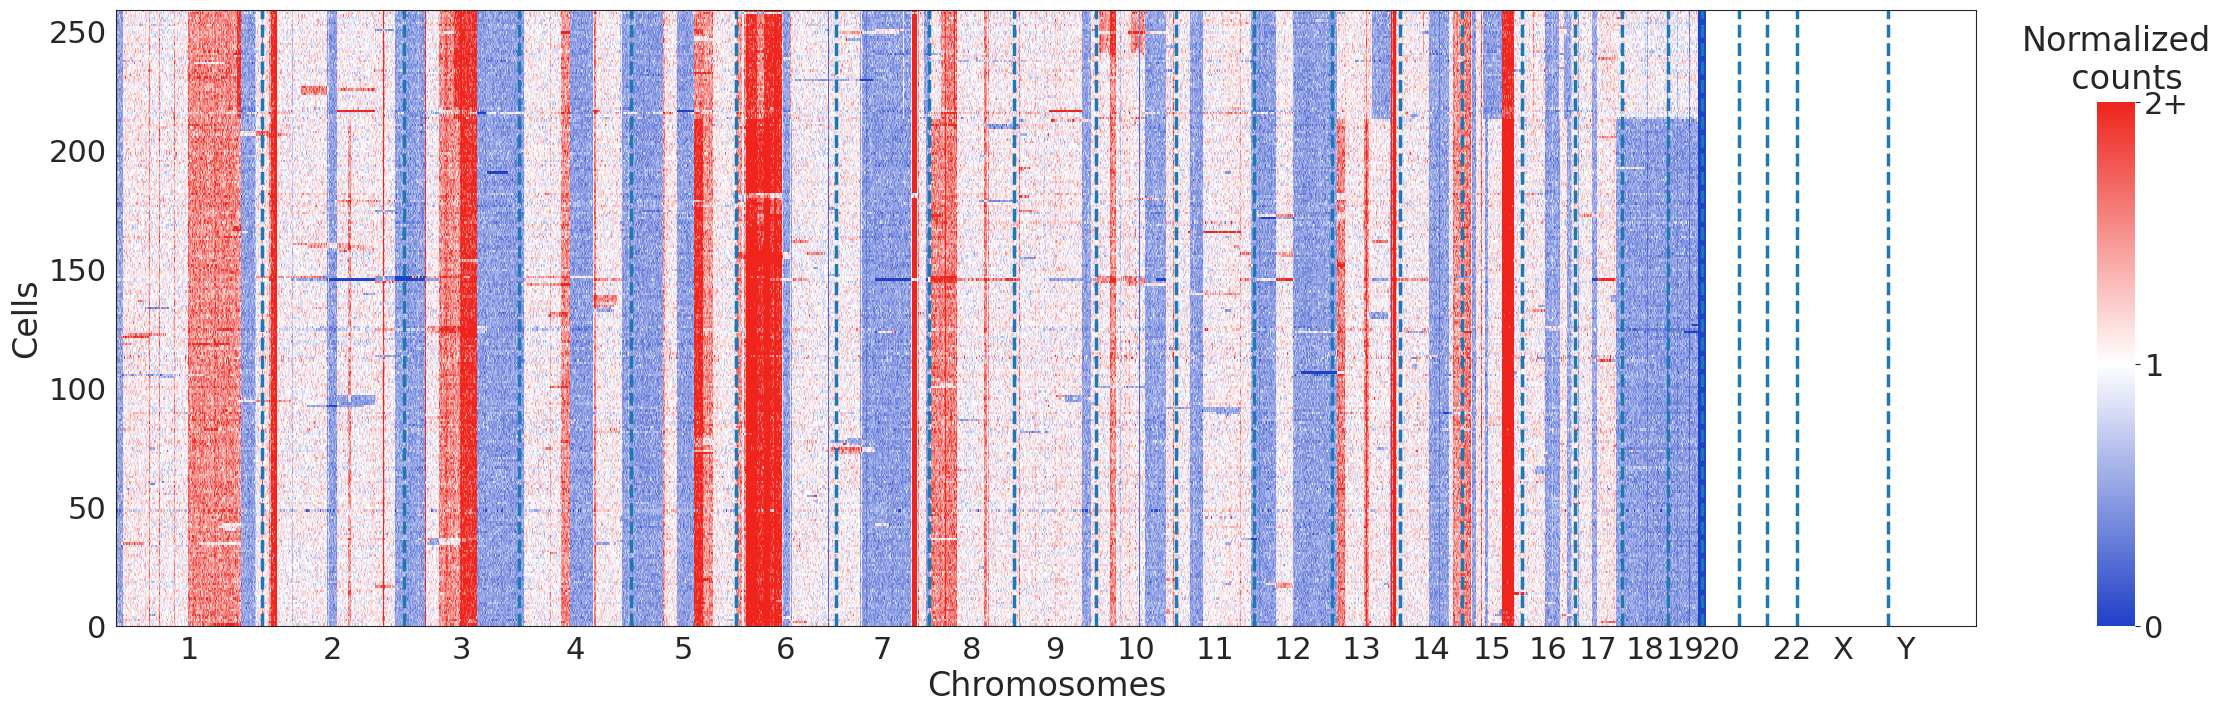

In [24]:
scicone.plotting.plot_matrix(
    normalized_counts,
    cbar_title='Normalized\n  counts',
    chr_stops_dict =chromosome_stops,
    vmax = 2,
    cluster=False  # don't cluster the cells for this plot, just to make it faster
)

In [ ]:
# Remove the 'mode' argument from detect_breakpoints call, since the C++ binary does not support it.
bps = sci.detect_breakpoints(
    data=filtered_counts,
    window_size = 100,
    threshold=3,
    input_breakpoints=chr_stops_list,
    bp_limit = 400
)

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.773979
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 6122.1
1660, 1662
1659, 1663
1658, 1664
1657, 1665
1656, 1666
1655, 1667
1654, 1668
1653, 1669
1652, 1670
1651, 1671
1650, 1672
1649, 1673
1648, 1674
1647, 1675
1646, 1676
1645, 1677
1644, 1678
1643, 1679
1642, 1680
1641, 1681
1640, 1682
1639, 1683
1638, 1684
1637, 1685
1636, 1686
1635, 1687
1634, 1688
1633, 1689
1632, 1690
Adding 1661: 612210
3282, 3284
3281, 3285
3280, 3286
3279, 3287
3278, 3288
3277, 3289
3276, 3290
3275, 3291
3274, 3292
3273, 3293
3272, 3294
3271, 3295
3270, 3296
3269, 3297
3268, 3298
3267, 3299
3266, 3300
3265, 3301
3264, 3302
3263, 3303
32

no breakpoints are found within the interval: (13887,13910)


Index of the maximum 13922 is added to all_max_ids.
Index of the maximum 5162 is added to all_max_ids.
Index of the maximum 9126 is added to all_max_ids.
Index of the maximum 1809 is added to all_max_ids.
Index of the maximum 15465 is added to all_max_ids.
Index of the maximum 5421 is added to all_max_ids.
Index of the maximum 7490 is added to all_max_ids.
Index of the maximum 6222 is added to all_max_ids.
Index of the maximum 7506 is added to all_max_ids.
Index of the maximum 16844 is added to all_max_ids.
Index of the maximum 7164 is added to all_max_ids.
Index of the maximum 41 is added to all_max_ids.
Index of the maximum 4634 is added to all_max_ids.
Index of the maximum 11117 is added to all_max_ids.
Index of the maximum 11008 is added to all_max_ids.
Index of the maximum 2494 is added to all_max_ids.
Index of the maximum 16901 is added to all_max_ids.
Index of the maximum 17111 is added to all_max_ids.
Index of the maximum 3036 is added to all_max_ids.
Index of the maximum 14981

no breakpoints are found within the interval: (15627,15644)


Index of the maximum 3904 is added to all_max_ids.
Index of the maximum 9927 is added to all_max_ids.
Index of the maximum 2616 is added to all_max_ids.


...

Index of the maximum 17547 is added to all_max_ids.
Index of the maximum 3775 is added to all_max_ids.
Index of the maximum 12011 is added to all_max_ids.
Index of the maximum 10734 is added to all_max_ids.
Index of the maximum 8977 is added to all_max_ids.
Index of the maximum 15697 is added to all_max_ids.


no breakpoints are found within the interval: (15669,15685)


Index of the maximum 11536 is added to all_max_ids.
Index of the maximum 1597 is added to all_max_ids.
Index of the maximum 8541 is added to all_max_ids.
Index of the maximum 16403 is added to all_max_ids.
Index of the maximum 11206 is added to all_max_ids.
Index of the maximum 16223 is added to all_max_ids.
Index of the maximum 12427 is added to all_max_ids.
Index of the maximum 2948 is added to all_max_ids.
Index of the maximum 17955 is added to all_max_ids.
Index of the maximum 638 is added to all_max_ids.
Index of the maximum 4953 is added to all_max_ids.
Index of the maximum 14375 is added to all_max_ids.
Index of the maximum 715 is added to all_max_ids.
Index of the maximum 6869 is added to all_max_ids.
Index of the maximum 2079 is added to all_max_ids.
Index of the maximum 13714 is added to all_max_ids.


no breakpoints are found within the interval: (11021,11035)


Index of the maximum 11047 is added to all_max_ids.
Index of the maximum 14959 is added to all_max_ids.
Index of the maximum 8963 is added to all_max_ids.
Index of the maximum 2517 is added to all_max_ids.
Index of the maximum 8121 is added to all_max_ids.
Index of the maximum 9381 is added to all_max_ids.
Index of the maximum 11573 is added to all_max_ids.
Index of the maximum 14697 is added to all_max_ids.
Index of the maximum 14676 is added to all_max_ids.
Index of the maximum 17644 is added to all_max_ids.
Index of the maximum 9798 is added to all_max_ids.
Index of the maximum 8458 is added to all_max_ids.
Index of the maximum 14080 is added to all_max_ids.
Index of the maximum 8277 is added to all_max_ids.
Index of the maximum 5562 is added to all_max_ids.
Index of the maximum 11254 is added to all_max_ids.
Index of the maximum 1072 is added to all_max_ids.
Index of the maximum 9427 is added to all_max_ids.
Index of the maximum 668 is added to all_max_ids.
Index of the maximum 168

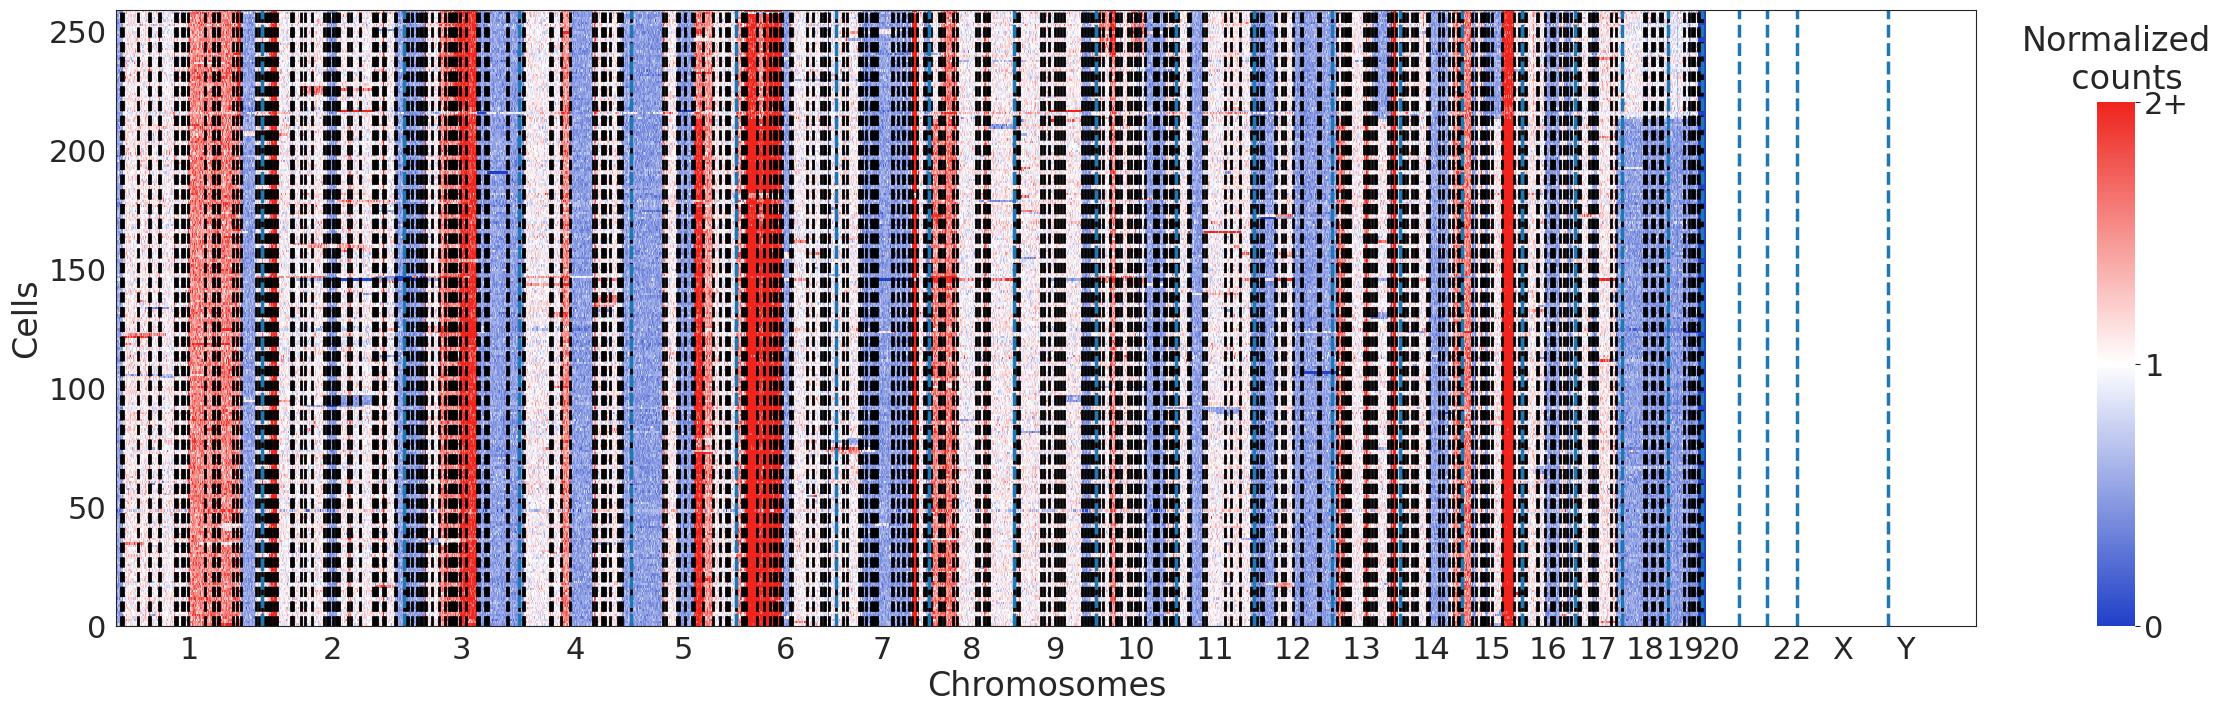

In [19]:
scicone.plotting.plot_matrix(normalized_counts, bps = bps['segmented_regions'],
                                    chr_stops_dict=chromosome_stops,
                                    cbar_title='Normalized\n  counts', vmax=2, cluster=False)


In [22]:
print(len(bps['segmented_regions']))

300
